# Single-band basics
Check display, likelihood calculation, especially gradient

In [16]:
%reset -f
%run setup_notebook.py

from importlib import reload
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
import numpy as np
from utilities.ipynb_docgen import show
from like3 import pixel_table as _pt; reload(_pt)
PixelTable = _pt.PixelTable
from like3 import sourcelist as _sl; reload(_sl)
SourceModel = _sl.SourceModel

pt = PixelTable('files/kerr/toby_v4.fits')
sm = SourceModel.from_fermi_catalog('Geminga', version='v36')
from like3 import main as _main; 

Loaded pixel table from "files/kerr/toby_v4.fits":
            42 bands Band(0, 4): PSF0@1.33 GeV nside 64 occ 1.001 ... Band(3, 11): PSF3@74.99 GeV nside 2048 occ 0.000
            193,317,496 photons
            8,240,918 pixels, order ring
            
Loaded Fermi 4FGL gll_psc_v36.fit: 7221 entries


In [35]:
reload(_main)
BandLikelihood = _main.BandLikelihood
band = pt[3,4]; 
bl = BandLikelihood(band, sm) ; bl

BandLikelihood(band=Band(3, 4): PSF3@1.33 GeV nside 256 occ 0.901, source_model=SourceModel: @Geminga (v36) 1 sources with 2 free parameters)

In [36]:
show("""### Check localization""")
src = sm[0]; sd0 = src.skydir; 
ra,dec = sd0.ra.deg, sd0.dec.deg; ra,dec

### Check localization

(np.float64(98.48500000000001), np.float64(17.772))

In [37]:
llz = bl.loglike();
llsurf = lambda x,y : bl.loglike(None, skydir=(x+ra,y+dec)) - llz
llsurf (0,0)

0.0

In [38]:
from scipy.optimize import curve_fit

# Generate a grid of (x, y) offsets around (ra, dec)
delta = 0.01  # degrees
x = np.linspace(-delta, delta, 11)
y = np.linspace(-delta, delta, 11)
xx, yy = np.meshgrid(x, y)
zz = np.array([llsurf(xi, yi) for xi, yi in zip(xx.ravel(), yy.ravel())]).reshape(xx.shape)

# Define a 2D quadratic function
def quad2d(xy, a, b, c, d, e, f):
    x, y = xy
    return a + b*x + c*y + d*x**2 + e*x*y + f*y**2

# Fit the quadratic surface
popt, pcov = curve_fit(quad2d, (xx.ravel(), yy.ravel()), zz.ravel())

print("Fitted quadratic coefficients:", popt)

Fitted quadratic coefficients: [-2.07541728e-03 -3.72678973e+03 -1.44333248e+03 -4.56073345e+05
 -7.42256298e+03 -5.15749467e+05]


In [41]:
# The center (x0, y0) of the 2D quadratic a + bx + cy + d*x^2 + e*x*y + f*y^2 is at the stationary point:
# x0 = (2cf - be) / (e^2 - 4df)
# y0 = (2bd - ce) / (e^2 - 4df)
# But more generally, solve for grad = 0:
# [b + 2d*x0 + e*y0] = 0
# [c + 2f*y0 + e*x0] = 0

a, b, c, d, e, f = popt

# Build and solve the linear system
A = np.array([[2*d, e],
              [e, 2*f]])
B = -np.array([b, c])
center = np.linalg.solve(A, B)
x0, y0 = center
print(f"Quadratic stationary point (center): x0={x0:.6f}, y0={y0:.6f}")

Quadratic stationary point (center): x0=-0.004075, y0=-0.001370


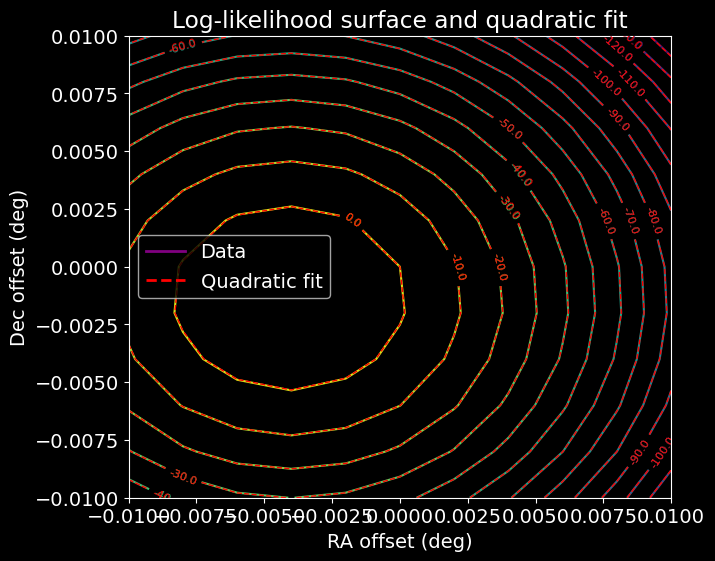

0.0

In [40]:
# Evaluate the fitted quadratic surface on the grid
zz_fit = quad2d((xx, yy), *popt)

plt.figure(figsize=(7, 6))
# Contour plot of the original log-likelihood surface
cont1 = plt.contour(xx, yy, zz, levels=15, cmap='viridis', linewidths=1.5)
plt.clabel(cont1, inline=True, fontsize=8, fmt="%.1f")

# Overlay contour plot of the fitted quadratic surface
cont2 = plt.contour(xx, yy, zz_fit, levels=cont1.levels, colors='r', linestyles='dashed', linewidths=1)
plt.clabel(cont2, inline=True, fontsize=8, fmt="%.1f")

plt.xlabel('RA offset (deg)')
plt.ylabel('Dec offset (deg)')
plt.title('Log-likelihood surface and quadratic fit')
# Fix legend for contour plots
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='purple', lw=2, label='Data'),
    Line2D([0], [0], color='red', lw=2, linestyle='dashed', label='Quadratic fit')
]
plt.legend(handles=legend_elements)
plt.show()
llsurf(0,0)

In [20]:
bl.loglike(None, skydir=(98.485, 17.772))-llz

1.7273423232254572

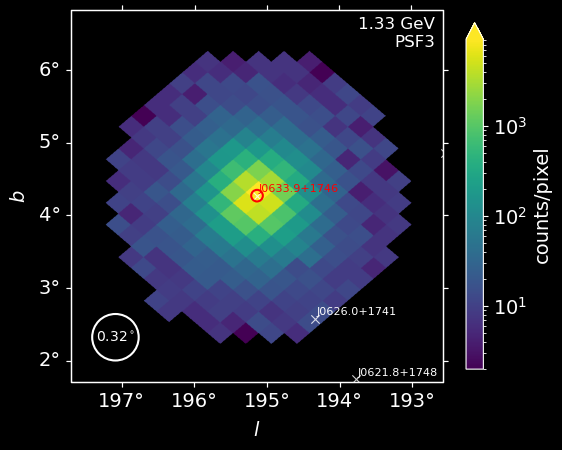

In [21]:
bl.zea_plot('photons');    

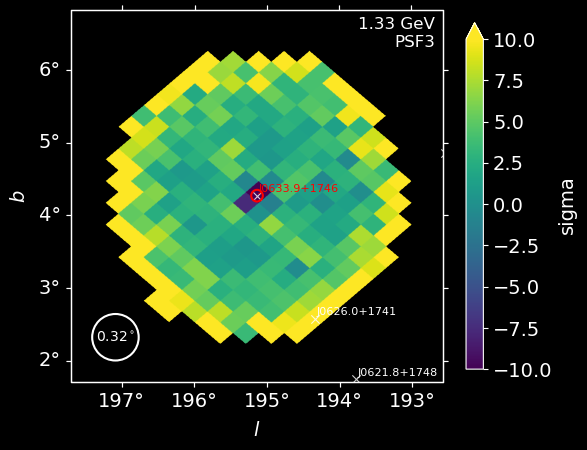

In [22]:
bl.zea_plot(bl.sigma, label='sigma', vmin=-10, vmax=10, log=False);   

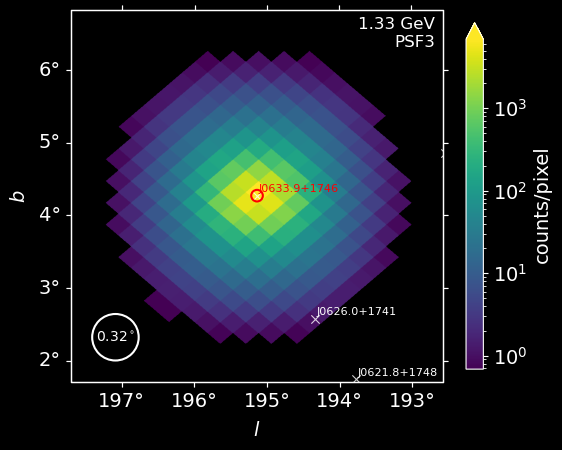

In [23]:
bl.zea_plot('source_counts');  

In [24]:
display(f""" ## Numerical gradient check for BandLikelihood""")
def numerical_gradient(loglike_fn, pars, eps=1e-3):
    """Compute numerical gradient of loglike_fn at pars using central differences."""
    grad = np.zeros_like(pars, dtype=float)
    for i in range(len(pars)):
        p_hi = np.array(pars, dtype=float)
        p_lo = np.array(pars, dtype=float)
        p_hi[i] += eps
        p_lo[i] -= eps
        f_hi = loglike_fn(p_hi)
        f_lo = loglike_fn(p_lo)
        grad[i] = (f_hi - f_lo) / (2 * eps)
    return grad

# Example usage: compare analytic and numerical gradients for BandLikelihood
pars0 = bl.parameters# if hasattr(bl.source_model, 'parameters') else np.concatenate([src.model.parameters[src.model.free] for src in bl.source_model])
ll, analytic_grad = bl.loglike_grad(pars0)
num_grad = numerical_gradient(lambda p: bl.loglike(p), pars0)
bl.parameters = pars0
print(f'Analytic gradient: {analytic_grad.round().astype(int)}')
print(f'Numerical gradient: {num_grad.round().astype(int)}')
print(f'Difference: {(analytic_grad - num_grad).round(1)}')

' ## Numerical gradient check for BandLikelihood'

Analytic gradient: [1761  205]
Numerical gradient: [1761  205]
Difference: [0.1 0. ]
